In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt 
from tqdm import tqdm
import torch
from PIL import Image  
import torch.optim as optim
from torch import nn


DATASETS_PATH = 'data/grid_generation/' #CHANGE HERE

In [ ]:
# Fraction of data used for training (remaining for validation/testing)
train_test_ratio = 0.8   

# Which GPUs to use (if available)
DEVICE_NUMBERS_TO_USE = [0, 1]  

# Batch size for all training/evaluation loops
BATCH_SIZE = 128     

# Number of input channels in your “states” (e.g. CLIP embeddings might be 1-channel grids)
NUM_CHANELS = 1

########################################################################################################
#
#    1. Load dataset
#
########################################################################################################
device = torch.device("cuda:"+str(DEVICE_NUMBERS_TO_USE[0]) if (len(DEVICE_NUMBERS_TO_USE) and torch.cuda.device_count() > 0) else "cpu")
print(f"device = {device}")

import pathlib
print(f"current path: {pathlib.Path().resolve()}")

# Create a timestamp for logging/output directories
from datetime import datetime
now = datetime.now()
current_time = now.strftime("%H:%M:%S")
global_datetime = str(now.date().year) + "_" + str(100 + now.date().month)[1:] + "_" + str(now.date().day) + "_" + str(current_time)

# These .npy files should have been produced by your prepare_data notebook/scripts
states = np.load(DATASETS_PATH+"states.npy",)
labels = np.load(DATASETS_PATH+"labels.npy",)
targets = np.load(DATASETS_PATH+"targets.npy",)
posteriors =  np.load(DATASETS_PATH+"posterior_distributions.npy",) 

# Print shapes for verification
print(f"states.shape = {states.shape}")  # Should be Nx3x128x128
print(f"labels.shape = {labels.shape}")  # Should be Nx2
print(f"targets.shape = {targets.shape}")  # Should be Nx1x128x128
print(f"posteriors.shape = {posteriors.shape}") 

device = cuda:0
current path: /media/alexander/DATA/sk_integration/notebooks
states.shape = (60105, 3, 128, 128)
labels.shape = (60105, 2)
targets.shape = (60105, 1, 128, 128)
posteriors.shape = (60105, 1, 128, 128)


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
########################################################################################################
#
#    2. Define dataloaders
#
########################################################################################################
# Split the data into training and testing sets
train_states, test_states, train_labels, test_labels, train_targets, test_targets, train_posteriors, test_posteriors = train_test_split(
    states, labels, targets, posteriors, train_size=train_test_ratio, random_state=42
)

In [ ]:
# Custom Dataset class
class CustomDataset(Dataset):
    def __init__(self, states, labels, targets, posteriors):
        self.states = states
        self.labels = labels
        self.targets = targets
        self.posteriors = posteriors

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        state = torch.tensor(self.states[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        target = torch.tensor(self.targets[idx], dtype=torch.float32).permute(0, 2, 1)
        posterior = torch.tensor(self.posteriors[idx], dtype=torch.float32).permute(0, 2, 1)
        return state, label, target, posterior

# Create the training dataset and DataLoader
train_dataset = CustomDataset(train_states, train_labels, train_targets, train_posteriors)
trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Verify shapes
image, target, params, pred_posterior = next(iter(trainloader))
print(f"train: image.shape = {image.shape}")  # Should be (BATCH_SIZE, NUM_CHANNELS, 128, 128)
print(f"train: target.shape = {target.shape}")  # Should be (BATCH_SIZE, 128, 128)
print(f"train: params.shape = {params.shape}")  # Should be (BATCH_SIZE, 128, 128)
print(f"train: pred_posterior.shape = {pred_posterior.shape}")  # Should be (BATCH_SIZE, 128, 128)

# Now ready to feed (state_batch, target_batch) into the U‑Net training loop,
# and use label_batch for any auxiliary losses or logging.

train: image.shape = torch.Size([128, 3, 128, 128])
train: target.shape = torch.Size([128, 2])
train: params.shape = torch.Size([128, 1, 128, 128])
train: pred_posterior.shape = torch.Size([128, 1, 128, 128])


In [6]:
import torch.nn.functional as F

class SoftmaxProbs(nn.Module):
    #Custom Linear layer but mimics a standard linear layer
    def __init__(self):
        super().__init__()
    def forward(self, res):
        return F.softmax(torch.flatten(res, start_dim=-2), dim=-1).view(*res.shape)

softmax_probs_unet = SoftmaxProbs()

In [ ]:
########################################################################################################
#
#    3. Define loss function for training convex NET
#
########################################################################################################
class CD_JSD_Loss(nn.Module):  
    """
    Combined loss = Jensen–Shannon divergence + normalized centroid distance
    between two 2D probability distributions P and Q on a fixed grid.
    """
    def __init__(self, x_min=0, x_max=1, y_min=0, y_max=1, grid_size=128, device='cpu'):
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max
        self.grid_size = grid_size
        self.device = device
        self.epsilon = 1e-8
        self.axis_x = torch.linspace(self.x_min, self.x_max, self.grid_size).unsqueeze(0).to(self.device)
        self.axis_y = torch.linspace(self.x_min, self.x_max, self.grid_size).unsqueeze(0).to(self.device)
        super(CD_JSD_Loss, self).__init__()  
  
    def entropy(self, probs):    
        return -torch.sum(probs*torch.log(probs+self.epsilon), dim=(-1,-2))  
  
    def jsd(self, prob_P, prob_Q):    
        """
        Compute symmetric Jensen–Shannon divergence:
        JSD(P||Q) = H((P+Q)/2) - 0.5 * [H(P) + H(Q)]
        """
        mean_prob = (prob_P+prob_Q)/2    
        return self.entropy(mean_prob)-(self.entropy(prob_P)+self.entropy(prob_Q))/2  
  
    def centroid_dist(self, prob_P, prob_Q):
        """
        Compute normalized Euclidean distance between centroids of P and Q.
        - Compute mean x-coordinate: sum_x (p(x,y) * x), similarly for y.
        - Normalize by sqrt(2) so max distance in unit square = 1.
        """    
        mean_axis_x = torch.einsum('ijkl,kl->ij', prob_Q, self.axis_x) - torch.einsum('ijkl,kl->ij', prob_P, self.axis_x)  
        mean_axis_y = torch.einsum('ijkl,kl->ij', prob_Q.transpose(-1,-2), self.axis_y) - torch.einsum('ijkl,kl->ij', prob_P.transpose(-1,-2), self.axis_y)  
        return torch.sqrt(mean_axis_x**2 + mean_axis_y**2) / np.sqrt(2)  
 
    def forward(self, prob_P, prob_Q):   
        """
        Compute the total loss:
        JSD(P||Q) + centroid distance(P, Q)
        """ 
        return self.jsd(prob_P, prob_Q)+self.centroid_dist(prob_P, prob_Q)


# Instantiate loss, moving all internal tensors to the selected device
cd_jsd_loss = CD_JSD_Loss(device=device)  

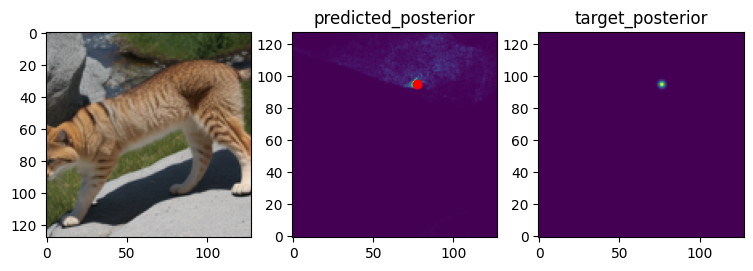

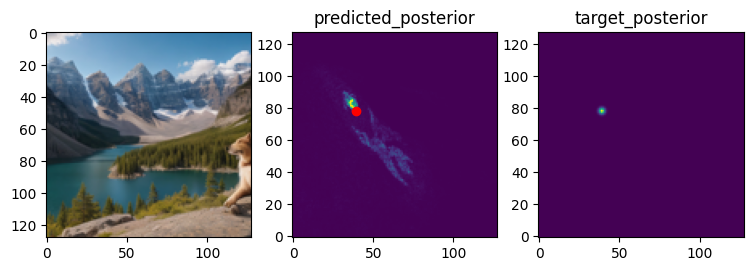

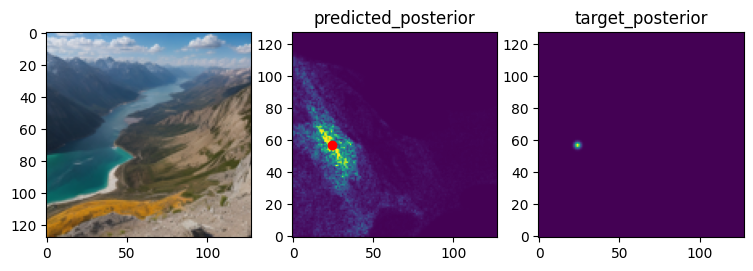

In [ ]:
# ------------------------------------------------------------
# 3.1 Sanity‑check a few samples from the training DataLoader
# ------------------------------------------------------------
for _ in range(3):
    image, parameters, target, posterior = next(iter(trainloader))

    target_posterior = target.to(device)    
    plt.figure(figsize=(3*3,3))
    plt.subplot(131)
    plt.imshow(image[0].permute(1, 2, 0).cpu().to(torch.uint8),origin="upper")
    plt.subplot(132)
    # Reference (CLIP‑based) posterior
    plt.imshow(posterior[0].permute(1, 2, 0).cpu(),origin="lower")
    # Overlay the true parameter location as a red marker
    plt.scatter( parameters[0].detach().cpu().numpy()[1]*128, parameters[0].detach().cpu().numpy()[0]*128, c='r')
    plt.title('predicted_posterior')
    plt.subplot(133)
    # Show the Gaussian‑smoothed target distribution
    plt.imshow(target_posterior[0].permute(1, 2, 0).cpu(),origin="lower")
    plt.title('target_posterior')
    plt.show();

In [ ]:
########################################################################################################
#
#    4. Define the neural network
#
########################################################################################################

# Define the neural network  
class Net(nn.Module):    
    def __init__(self, input_dim, hidden_dim, output_dim):    
        super(Net, self).__init__()    
        self.fc1 = nn.Linear(input_dim, hidden_dim)    
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)    
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)    
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)    
        self.fc5 = nn.Linear(hidden_dim, output_dim)  
  
        # Layer normalization layers  
        self.norm1 = nn.LayerNorm(hidden_dim)  
        self.norm2 = nn.LayerNorm(hidden_dim)  
        self.norm3 = nn.LayerNorm(hidden_dim)  
        self.norm4 = nn.LayerNorm(hidden_dim)  
    
    def forward(self, x):    
        x = torch.relu(self.norm1(self.fc1(x)))    
        x = torch.relu(self.norm2(self.fc2(x)))    
        x = torch.relu(self.norm3(self.fc3(x)))    
        x = torch.relu(self.norm4(self.fc4(x)))  
        x = self.fc5(x)  
        return x  

from torch.nn.functional import softmax  
  
# Define the function to compute softmax probabilities  
def softmax_probs(scores):  
    probs = softmax(scores, dim=0)  
    return probs  

# Compute the gradients of log_Z with respect to the input points  
def compute_grad_log_Z(model, points):  
    # Forward pass  
    log_Z = model(points)  
      
    # Compute gradients  
    # Since we are using batched input, we need to specify that we want gradients for each item in the batch  
    grad_log_Z = torch.autograd.grad(outputs=log_Z, inputs=points, grad_outputs=torch.ones_like(log_Z), create_graph=True)[0]  
      
    return grad_log_Z, log_Z  
  
# Compute the probability distribution on the domain with coordinates base_points  
def compute_probs(model, base_points, t_prime):  
    # Initialize a list to store the softmax probabilities for each t_prime  
    probs_list = []  
      
    # Compute log_Z at base_points  
    log_Z_base = model(base_points)  
      
    for t in t_prime:  
        # Compute grad(log_Z) at point t  
        grad_log_Z_t, _ = compute_grad_log_Z(model, t.unsqueeze(0))  
          
        # Compute scores for softmax  
        scores = -1000 * (grad_log_Z_t @ base_points.T - log_Z_base.T).squeeze()  
          
        # Compute softmax probabilities and add to the list  
        probs_list.append(softmax_probs(scores))  
      
    # Concatenate the list of tensors along the first dimension to get the final probs tensor  
    probs = torch.stack(probs_list)  
      
    return probs  
    
def compute_conv_loss(model, num_samples = 300):
    # Compute convexity loss  
    # number of random pairs to sample for convexity loss  
    a = torch.rand(num_samples, 2).to(device)  
    b = torch.rand(num_samples, 2).to(device)  
    f_a = model(a)  
    f_b = model(b)  
    f_mid = model((a + b) / 2)  

    # Add a penalty if the convexity constraint is violated  
    convexity_loss = torch.relu((f_a + f_b) / 2-f_mid).mean()
    return convexity_loss

In [10]:
# Create the neural network and move it to GPU if available  
model = Net(2, 512, 1).to(device)  

/home/alexander/research/lib/python3.10/site-packages/torch/autograd/graph.py:768: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


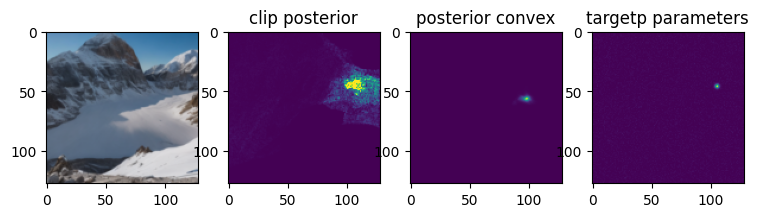

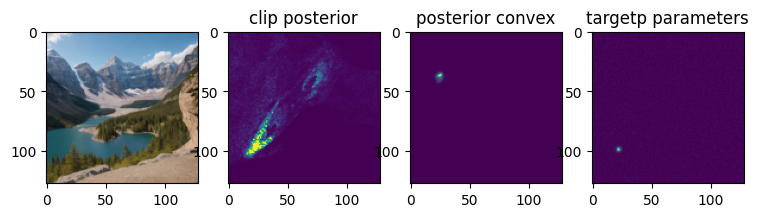

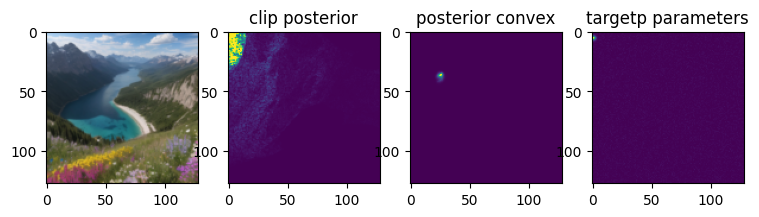

In [ ]:
# ------------------------------------------------------------
# 4.1 Sanity‑check a few samples from the training DataLoader with the model
# ------------------------------------------------------------

for _ in range(3):
    image, parameters, target, posterior = next(iter(trainloader))

    target_posterior = target.to(device)
    target_posterior = softmax_probs_unet(torch.abs(torch.randn_like(target_posterior))/50+target_posterior)



    image_size = 128  
    linspaceX = torch.linspace(0.,1,steps=image_size)  
    linspaceY = torch.linspace(0.,1,steps=image_size)  
    base_points = torch.cartesian_prod(linspaceX, linspaceY)  
    base_points.requires_grad = True  
    base_points = base_points.to(device)  
    parameters = parameters.to(device)
    parameters.requires_grad = True  
    # Compute probability distribution  
    probs = compute_probs(model, base_points, parameters) 
    predicted_posterior_from_convex = probs.reshape(-1,1,image_size, image_size)
    

    plt.figure(figsize=(3*3,3))
    plt.subplot(141)
    plt.imshow(image[0].permute(1, 2, 0).cpu().to(torch.uint8))
    plt.subplot(142)
    plt.imshow(posterior[0].permute(1, 2, 0).cpu())
    plt.title('clip posterior')
    plt.subplot(143)
    plt.imshow(predicted_posterior_from_convex[0].cpu().detach().numpy()[0], origin="upper")
    plt.title('posterior convex')
    plt.subplot(144)
    plt.imshow(target_posterior[0].permute(1, 2, 0).cpu())
    plt.title('targetp parameters')
    plt.show();


In [ ]:
# -----------------------------------
# 5. Training loop for convex free‑energy model
# -----------------------------------


image_size = 128  
# Set the loss function and the optimizer  
mse_loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  

for epoch in range(30):
    print(f"Starting epoch={epoch} ...")
    loss_mean = []
    counter = 0
    for _, batch_parameters, _,  batch_posteriors  in tqdm(trainloader):
        
        optimizer.zero_grad()
        
        parameters = batch_parameters.to(device)
        predicted_posterior = batch_posteriors.to(device)

        # Create a (image_size^2, 2) tensor of all (x,y) coordinates
        linspaceX = torch.linspace(0.,1,steps=image_size)  
        linspaceY = torch.linspace(0.,1,steps=image_size)  
        base_points = torch.cartesian_prod(linspaceX, linspaceY)  
        base_points.requires_grad = True  
        base_points = base_points.to(device)  

        parameters = parameters.to(device)
        parameters.requires_grad = True  


        # compute_probs wraps our model: it takes base_points and parameters
        # and returns a flat vector of probabilities for each (x,y).
        probs = compute_probs(model, base_points, parameters) 
        predicted_posterior_from_convex = probs.reshape(-1,1,image_size, image_size)

        jsd_loss = cd_jsd_loss(predicted_posterior, predicted_posterior_from_convex).mean()
        # Optional: direct MSE loss on the distributions
        # mse_loss = mse_loss_fn(predicted_posterior_from_convex, predicted_posterior).mean()
        convexity_loss = compute_conv_loss(model).mean()

        # Total loss: you can toggle terms on/off by commenting them
        loss = jsd_loss  + convexity_loss # + mse_loss


        loss_mean.append(loss.item())

        loss.backward()
        optimizer.step()
        
        counter += 1
        if counter%20 == 0:
            print(np.mean(loss_mean[-90:]))
            # print(torch.linalg.norm(buf-predicted_posterior))
            
    print(np.mean(loss_mean))

In [26]:
model.load_state_dict(torch.load("conv_model_diff_clip_v1.pt"))

/tmp/ipykernel_3501567/3020597034.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("conv_model_diff_clip_v1.pt"))


<All keys matched successfully>

/tmp/ipykernel_3501567/1770336594.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


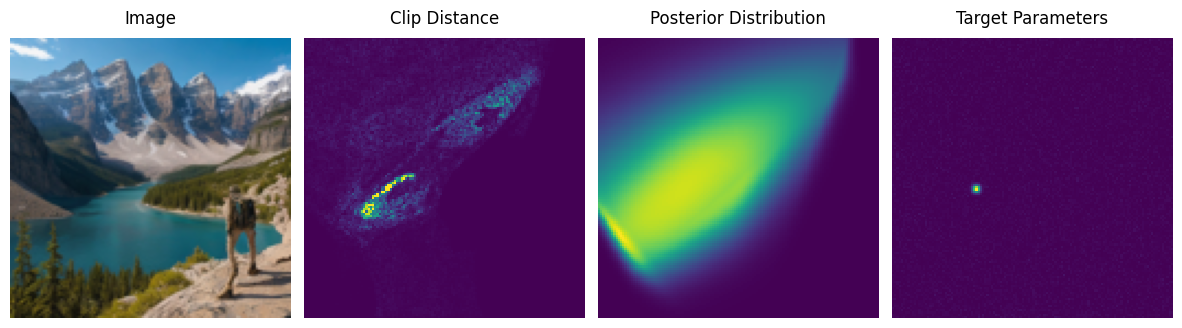

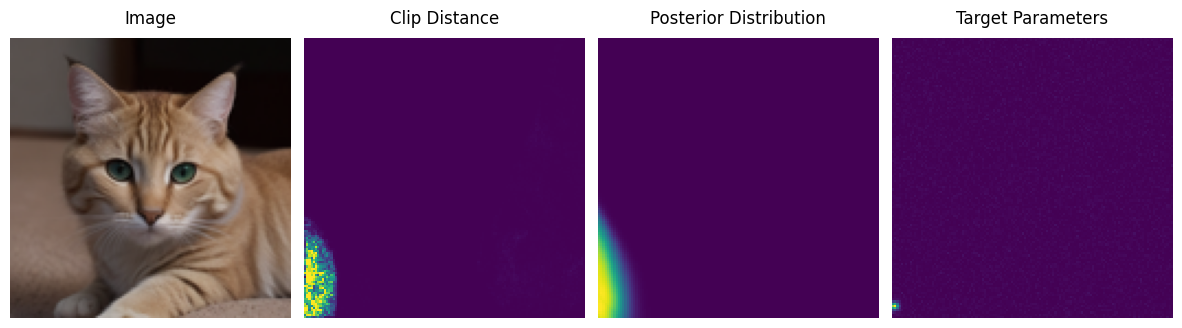

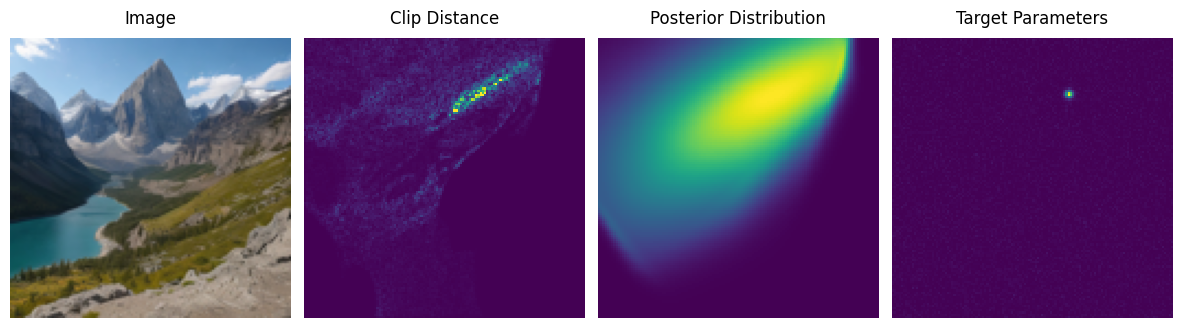

In [ ]:
# ------------------------------------------------------------
# 4.1 Sanity‑check a few samples from the training DataLoader with the model
# ------------------------------------------------------------


for _ in range(3):
    image, parameters, target, posterior = next(iter(trainloader))
    
    target_posterior = target.to(device)
    target_posterior = softmax_probs_unet(torch.abs(torch.randn_like(target_posterior))/50+target_posterior)

    image_size = 128  
    linspaceX = torch.linspace(0.,1,steps=image_size)  
    linspaceY = torch.linspace(0.,1,steps=image_size)  
    base_points = torch.cartesian_prod(linspaceX, linspaceY)  
    base_points.requires_grad = True  
    base_points = base_points.to(device)  
    parameters = parameters.to(device)
    parameters.requires_grad = True  
    
    # Compute probability distribution  
    probs = compute_probs(model, base_points, parameters) 
    predicted_posterior_from_convex = probs.reshape(-1,1,image_size, image_size)
    
    # Create figure with 4 subplots
    fig, axs = plt.subplots(1, 4, figsize=(15, 4), 
                           gridspec_kw={'wspace': 0.05, 'hspace': 0})
    
    # Common image parameters
    img_params = {'cmap': 'viridis', 'interpolation': 'nearest', 'origin': 'upper'}
    
    # Plot RGB Image
    axs[0].imshow(image[0].permute(1, 2, 0).cpu().to(torch.uint8))
    axs[0].set_title('Image', fontsize=12, pad=10)
    
    # Clip Distance
    axs[1].imshow(posterior[0].squeeze().cpu().numpy().T, **img_params)
    axs[1].set_title('Clip Distance', fontsize=12, pad=10)
    
    # Posterior Distribution
    axs[2].imshow(predicted_posterior_from_convex[0].squeeze().cpu().detach().numpy().T, **img_params)
    axs[2].set_title('Posterior Distribution', fontsize=12, pad=10)
    
    # Target Parameters
    axs[3].imshow(target_posterior[0].squeeze().cpu().numpy().T, **img_params)
    axs[3].set_title('Target Parameters', fontsize=12, pad=10)
    
    # Formatting
    for ax in axs:
        ax.axis('off')
        ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

In [ ]:

# --------------------------------------------
# 5. Compute first and second derivatives of log‑partition (free energy)
# --------------------------------------------

# Create a grid of points in the unit square [0, 1] x [0, 1]
image_size = 128
# Prepare a uniform grid of (T, H) points over [0,1]×[0,1]
linspaceX = torch.linspace(0.,1,steps=image_size)
linspaceY = torch.linspace(0.,1,steps=image_size)
# Create all (T, H) pairs; shape = (image_size**2, 2)
base_points = torch.cartesian_prod(linspaceX, linspaceY)
base_points.requires_grad = True
base_points = base_points.to(device)


base_points_tens = base_points.detach()


In [ ]:
#  Forward pass: compute log‑partition values at each grid point
# model convex network that outputs log_Z for each (T, H)

log_Z = model(base_points)

# First derivatives: ∂Z/∂T and ∂Z/∂H (i.e., expected sufficient statistics)
grad_outputs = torch.ones_like(log_Z)
gradients = torch.autograd.grad(outputs=log_Z, inputs=base_points,
                                grad_outputs=grad_outputs, create_graph=True)[0]

dfdT = gradients[:, 0]
dfdH = gradients[:, 1]

# Convert log_Z to NumPy for external analysis or plotting
zdata = log_Z.unsqueeze(1).cpu().detach().flatten().numpy() 

# Second derivatives (Hessian entries)
# Compute the gradient of dfdT with respect to base_points
d2fdT2 = torch.autograd.grad(outputs=dfdT, inputs=base_points,
                             grad_outputs=torch.ones_like(dfdT), create_graph=True)[0][:, 0]

d2fdTdH = torch.autograd.grad(outputs=dfdT, inputs=base_points,
                              grad_outputs=torch.ones_like(dfdT), create_graph=True)[0][:, 1]

# Compute the gradient of dfdH with respect to base_points
d2fdHdT = torch.autograd.grad(outputs=dfdH, inputs=base_points,
                              grad_outputs=torch.ones_like(dfdH), create_graph=True)[0][:, 0]

d2fdH2 = torch.autograd.grad(outputs=dfdH, inputs=base_points,
                             grad_outputs=torch.ones_like(dfdH), create_graph=True)[0][:, 1]


dfdT = dfdT.cpu().detach().numpy()
dfdH = dfdH.cpu().detach().numpy()

# Detach and convert to numpy arrays
d2fdT2 = d2fdT2.cpu().detach().numpy()
d2fdTdH = d2fdTdH.cpu().detach().numpy()
d2fdHdT = d2fdHdT.cpu().detach().numpy()
d2fdH2 = d2fdH2.cpu().detach().numpy()

# Now you have the second derivatives in numpy arrays
print("d2fdT2:", d2fdT2)
print("d2fdTdH:", d2fdTdH)
print("d2fdHdT:", d2fdHdT)
print("d2fdH2:", d2fdH2)

d2fdT2: [-0.00438513 -0.0043848  -0.00433558 ... -0.01802985 -0.01832998
 -0.0183209 ]
d2fdTdH: [-0.00273568 -0.00273943 -0.00246924 ...  0.00795776  0.00781885
  0.00777771]
d2fdHdT: [-0.00273568 -0.00273943 -0.00246924 ...  0.00795776  0.00781884
  0.00777771]
d2fdH2: [-0.01591357 -0.01586545 -0.01558013 ...  0.00157855  0.00153521
  0.00154799]


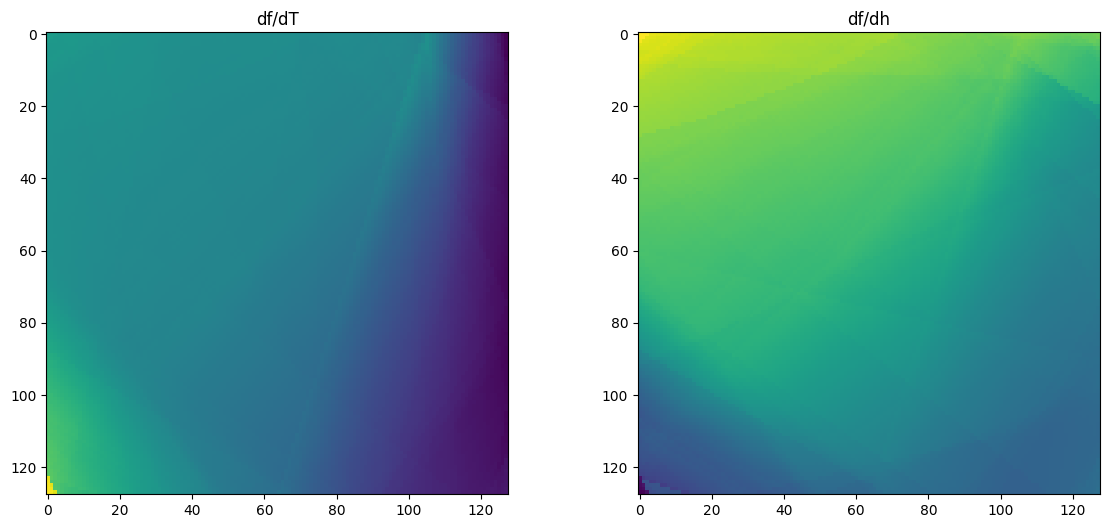

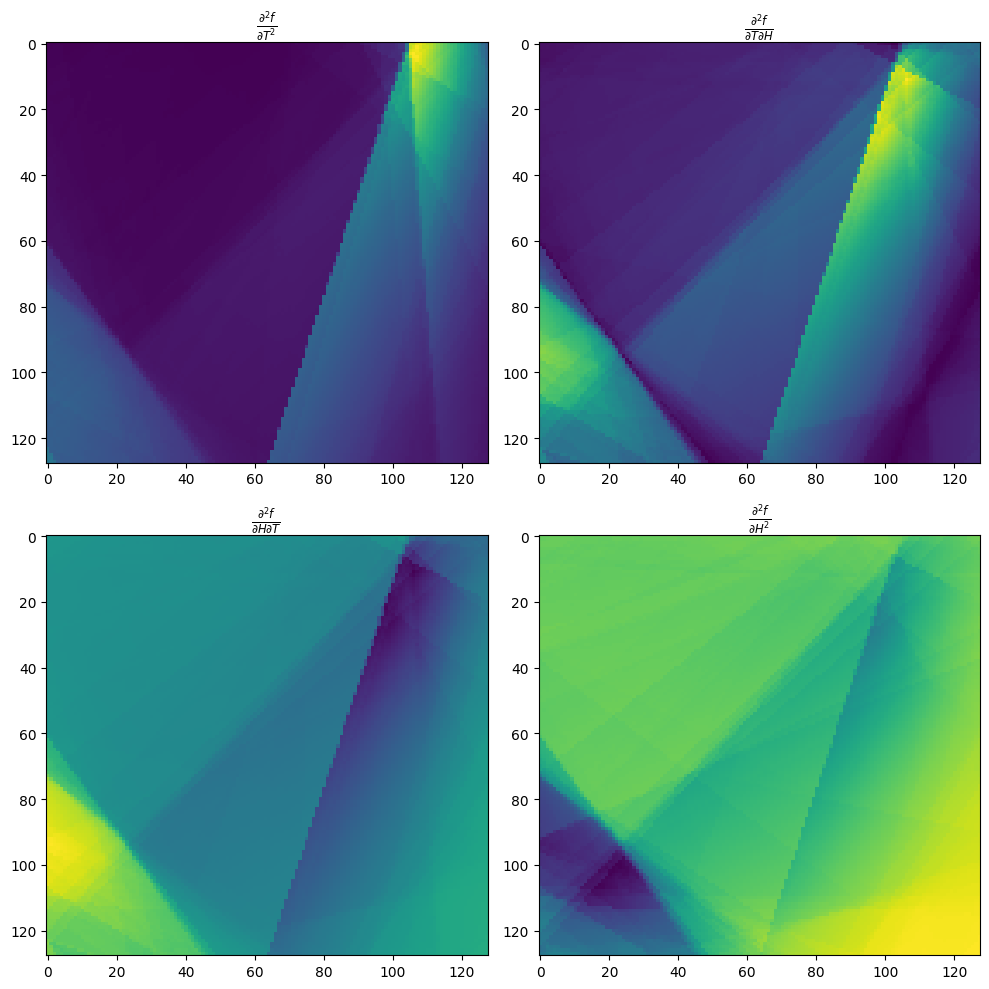

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have already computed the second derivatives as numpy arrays
# d2fdT2, d2fdTdH, d2fdHdT, d2fdH2

plt.figure(figsize=(14,6))
plt.subplot(121)
plt.imshow(dfdT.reshape(image_size,image_size).T, origin='upper')
plt.title('df/dT')
plt.subplot(122)
plt.imshow(dfdH.reshape(image_size,image_size).T, origin='upper')
plt.title('df/dh')
plt.show()

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Plot each second derivative using imshow
im1 = axes[0, 0].imshow(np.abs(d2fdT2.reshape(image_size,image_size).T), cmap='viridis', aspect='auto')
axes[0, 0].set_title(r'$\frac{\partial^2 f}{\partial T^2}$')
# fig.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].imshow(np.abs(d2fdTdH.reshape(image_size,image_size).T), cmap='viridis', aspect='auto')
axes[0, 1].set_title(r'$\frac{\partial^2 f}{\partial T \partial H}$')
# fig.colorbar(im2, ax=axes[0, 1])

im3 = axes[1, 0].imshow(d2fdHdT.reshape(image_size,image_size).T, cmap='viridis', aspect='auto')
axes[1, 0].set_title(r'$\frac{\partial^2 f}{\partial H \partial T}$')
# fig.colorbar(im3, ax=axes[1, 0])

im4 = axes[1, 1].imshow(d2fdH2.reshape(image_size,image_size).T, cmap='viridis', aspect='auto')
axes[1, 1].set_title(r'$\frac{\partial^2 f}{\partial H^2}$')
# fig.colorbar(im4, ax=axes[1, 1])

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()